# **MÓDULO 35 - Cross Validation**

Nesta tarefa, você trabalhará com uma base de dados que contém informações sobre variáveis ambientais coletadas para a detecção de incêndios. O objetivo é utilizar técnicas de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação na previsão da ocorrência de um incêndio com base nas variáveis fornecidas.


**Descrição da Base de Dados**

A base de dados contém as seguintes variáveis:

- `Unnamed`:0: Índice (não é uma variável útil para o modelo)
- `UTC`: Tempo em Segundos UTC
- `Temperature[C]`: Temperatura do Ar (em graus Celsius)
- `Humidity[%]`: Umidade do Ar (em porcentagem)
- `TVOC[ppb]`: Total de Compostos Orgânicos Voláteis (medido em partes por bilhão)
- `eCO2[ppm]`: Concentração equivalente de CO2 (medido em partes por milhão)
- `Raw H2`: Hidrogênio molecular bruto, não compensado
- `Raw Ethanol`: Etanol gasoso bruto
- `Pressure[hPA]`: Pressão do Ar (em hectopascais)
- `PM1.0`: Material particulado de tamanho < 1,0 µm
- `PM2.5`: Material particulado de tamanho >1,0 µm e < 2,5 µm
- `NC0.5`: Concentração numérica de material particulado de tamanho < 0,5 µm
- `NC1.0`: Concentração numérica de material particulado de tamanho 0,5 µm < 1,0 µm
- `NC2.5`: Concentração numérica de material particulado de tamanho 1,0 µm < 2,5 µm
- `CNT`: Contador de amostras

E a variável *alvo*:
- `Fire Alarm`: Indicador binário de incêndio (1 se houver incêndio, 0 caso contrário)

O objetivo desta tarefa é aplicar a técnica de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação. A validação cruzada ajudará a garantir que o modelo seja avaliado de maneira robusta e generalize bem para dados não vistos.

In [15]:
# BIBLIOTECAS UTILIZADAS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

# 1 - Carregue a base de dados, verifique os tipos de dados e também se há presença de dados faltantes ou nulos.

In [16]:
# IMPORTAÇÃO DE DADOS

df = pd.read_csv('data.csv')

In [17]:
# PADRONIZAÇÃO DE COLUNAS E ELIMINAÇÃO DE COLUNA DESNECESSÁRIA

df.drop('Unnamed: 0', axis=1, inplace=True)
df.columns = df.columns.str.upper().str.replace(' ', '_')

In [18]:
# VERIFICAÇÃO DE TIPOS DE DADOS

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62630 non-null  int64  
 1   TEMPERATURE[C]  62630 non-null  float64
 2   HUMIDITY[%]     62630 non-null  float64
 3   TVOC[PPB]       62630 non-null  int64  
 4   ECO2[PPM]       62630 non-null  int64  
 5   RAW_H2          62630 non-null  int64  
 6   RAW_ETHANOL     62630 non-null  int64  
 7   PRESSURE[HPA]   62630 non-null  float64
 8   PM1.0           62630 non-null  float64
 9   PM2.5           62630 non-null  float64
 10  NC0.5           62630 non-null  float64
 11  NC1.0           62630 non-null  float64
 12  NC2.5           62630 non-null  float64
 13  CNT             62630 non-null  int64  
 14  FIRE_ALARM      62630 non-null  int64  
dtypes: float64(8), int64(7)
memory usage: 7.2 MB


In [19]:
# VERIFICAÇÃO DE DADOS NULOS

df.isnull().mean() * 100

UTC               0.0
TEMPERATURE[C]    0.0
HUMIDITY[%]       0.0
TVOC[PPB]         0.0
ECO2[PPM]         0.0
RAW_H2            0.0
RAW_ETHANOL       0.0
PRESSURE[HPA]     0.0
PM1.0             0.0
PM2.5             0.0
NC0.5             0.0
NC1.0             0.0
NC2.5             0.0
CNT               0.0
FIRE_ALARM        0.0
dtype: float64

Sem dados nulos. Não é necessário tratamento.

# 2 - Para essa base, onde você realizará as previsões de fire alarm, qual modelo de machine learning você aplicará? Justifique.




Para a realização da tarefa, farei alguns testes com os modelos: Random Forest e Regressão logística. Escolhi esses modelos por serem modelos de classificação robustos e que levam várias variáveis em sua aplicação. 

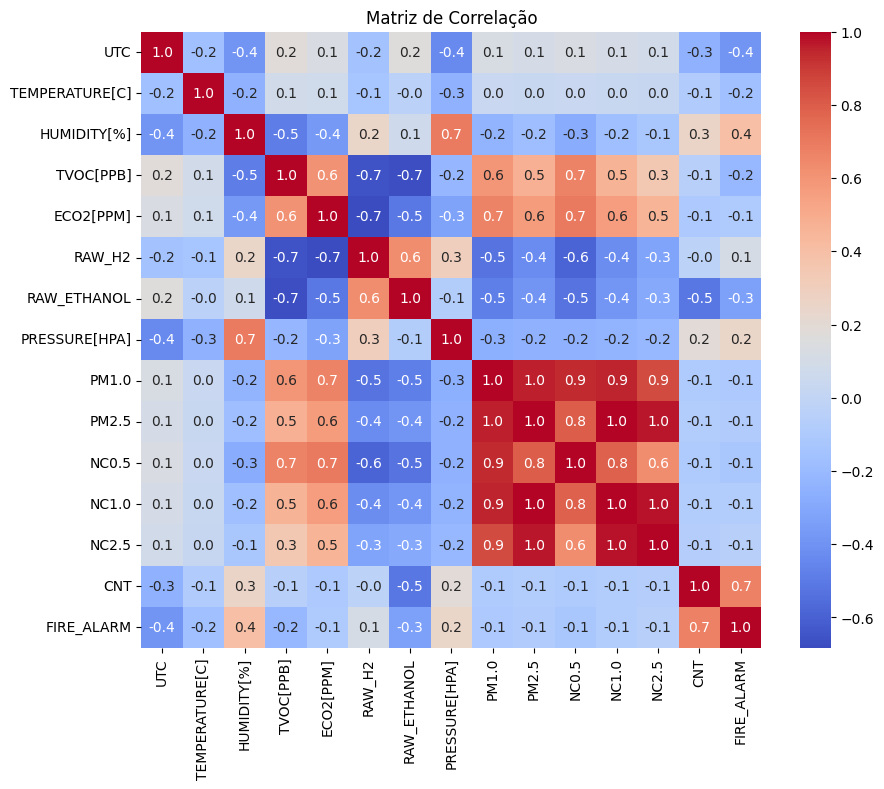

In [20]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Temos que as variáveis que estão mais correlacionadas com a variável target são:

- `CNT`: +0.7
- `UTC`: -0.4
- `HUMIFITY`: 0.4
- `RAW_ETHANOL`: -0.3
- `TEMPERATURE`: -0.2
- `TVOC`: -0.2
- `PRESSURE`: +0.2

As demais variáveis correspondem a apenas 0.1 ou - 0.1. A partir deste fato, vamos realizar a simplificação do DataFrame e a criação do DataFrame reduzido.

In [21]:
# CRIAÇÃO DE DATAFRAME REDUZIDO E PADRONIZAÇÃO

df_reduzido = df.copy()
df_reduzido = df_reduzido[['HUMIDITY[%]', 'RAW_ETHANOL', 'TEMPERATURE[C]', 'TVOC[PPB]', 'PRESSURE[HPA]', 'FIRE_ALARM']]
scaler = StandardScaler()

colunas_padronizadas = ['HUMIDITY[%]', 'RAW_ETHANOL', 'TEMPERATURE[C]', 'TVOC[PPB]', 'PRESSURE[HPA]']
df_reduzido[colunas_padronizadas] = scaler.fit_transform(df_reduzido[colunas_padronizadas])

# 3 - Separe a base em Y e X e já rode a instância do modelo que você utilizará.

In [22]:
# SEPARANDO OS DADOS DE TREINO E TESTE

x_train, x_test, y_train, y_test = train_test_split(df_reduzido.drop('FIRE_ALARM', axis=1), df_reduzido['FIRE_ALARM'], test_size=0.25, random_state=0)

In [23]:
# BALANCEAMENTO DA BASE DE TREINO

smote = SMOTE(random_state=0)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

In [24]:
# RANDOM FOREST

random_forest = RandomForestClassifier(random_state=0)
random_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# REGRESSÃO LOGÍSTICA 

logistic_regression = LogisticRegression(random_state = 0)
logistic_regression.fit(x_train_balanced, y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

# 4 - Defina o número de Folds e rode o modelo com a validação cruzada.

In [26]:
# CROSSVALIDATION

folds = 10
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=0)

# 5 - Avalie a pontuação de cada modelo e ao final a validação final da média.

In [27]:
# SCORE DA REGRESSÃO LOGÍSTICA

score_logistic_treino = cross_val_score(
    logistic_regression,
    x_train_balanced,
    y_train_balanced,
    cv=folds
)

score_logistic_teste = cross_val_score(
    logistic_regression,
    x_test,
    y_test,
    cv=folds
)

In [28]:
# SCORE DO RANDOM FOREST

score_random_forest_treino = cross_val_score(
    random_forest,
    x_train_balanced,
    y_train_balanced,
    cv=folds
)

score_random_forest_teste = cross_val_score(
    random_forest,
    x_test,
    y_test,
    cv=folds
)

In [29]:
# APRESENTAÇÃO DE RESULTADOS

print("REGRESSÃO LOGISTICA (TREINO)")
print(f'Acurácia (Score): {score_logistic_treino.mean():.3f}')

print("\nREGRESSÃO LOGISTICA (TESTE)")
print(f'Acurácia (Score): {score_logistic_teste.mean():.3f}')

print("\nRANDOM FOREST (TREINO)")
print(f'Acurácia (Score): {score_random_forest_treino.mean():.3f}')

print("\nRANDOM FOREST (TESTE)")
print(f'Acurácia (Score): {score_random_forest_treino.mean():.3f}')


REGRESSÃO LOGISTICA (TREINO)
Acurácia (Score): 0.868

REGRESSÃO LOGISTICA (TESTE)
Acurácia (Score): 0.870

RANDOM FOREST (TREINO)
Acurácia (Score): 1.000

RANDOM FOREST (TESTE)
Acurácia (Score): 1.000


**ANÁLISE:** A partir dos resultados, podemos indicar que o modelo de RANDOM FOREST atingiu a perfeição no teste com aproveitamento de 100%, tanto na base de treino, quanto na base de teste (indicando assim que não houve overfitting - confirmação na seção abaixo). Além disso, vale destacar que a regressão logística também teve resultados excelentes.

**OBSERVAÇÃO:** Fomos apresentados durante a aula à função `cross_val_score` que, segundo a [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) recebe apenas um parâmetro em `scoring`. A documentação indica o uso da função `cross_validate` que aceita mais parâmetros. A fim de complementar a atividade, deixo abaixo como exploração os resultados do uso dessa nova função:

In [30]:
# MÉTRICAS DA REGRESSÃO LOGÍSTICA

metricas_logistic_treino = cross_validate(
    logistic_regression,
    x_train_balanced,
    y_train_balanced,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)


metricas_logistic_teste = cross_validate(
    logistic_regression,
    x_test,
    y_test,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

In [31]:
# MÉTRICAS DO RANDOM FOREST

metricas_random_forest_treino = cross_validate(
    random_forest,
    x_train_balanced,
    y_train_balanced,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)


metricas_random_forest_teste = cross_validate(
    random_forest,
    x_test,
    y_test,
    cv=crossvalidation,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

In [32]:
# APRESENTAÇÃO DE RESULTADOS

print("REGRESSÃO LOGÍSTICA (TREINO)")
print(f'Acurácia: {metricas_logistic_treino["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_logistic_treino["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_logistic_treino["test_recall"].mean():.3f}')   
print(f'F1: {metricas_logistic_treino["test_f1"].mean():.3f}')   


print("\nREGRESSÃO LOGÍSTICA(TESTE)")
print(f'Acurácia: {metricas_logistic_teste["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_logistic_teste["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_logistic_teste["test_recall"].mean():.3f}')   
print(f'F1: {metricas_logistic_teste["test_f1"].mean():.3f}')   

print("\nRANDOM FOREST (TREINO)")
print(f'Acurácia: {metricas_random_forest_treino["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_random_forest_treino["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_random_forest_treino["test_recall"].mean():.3f}')   
print(f'F1: {metricas_random_forest_treino["test_f1"].mean():.3f}')  


print("\nRANDOM FOREST (TESTE)")
print(f'Acurácia: {metricas_random_forest_teste["test_accuracy"].mean():.3f}')
print(f'Precisão: {metricas_random_forest_teste["test_precision"].mean():.3f}')   
print(f'Recall: {metricas_random_forest_teste["test_recall"].mean():.3f}')   
print(f'F1: {metricas_random_forest_teste["test_f1"].mean():.3f}')  


REGRESSÃO LOGÍSTICA (TREINO)
Acurácia: 0.867
Precisão: 0.880
Recall: 0.851
F1: 0.865

REGRESSÃO LOGÍSTICA(TESTE)
Acurácia: 0.869
Precisão: 0.896
Recall: 0.924
F1: 0.910

RANDOM FOREST (TREINO)
Acurácia: 1.000
Precisão: 1.000
Recall: 1.000
F1: 1.000

RANDOM FOREST (TESTE)
Acurácia: 1.000
Precisão: 1.000
Recall: 1.000
F1: 1.000


**ANÁLISE:** Temos através destes resultados mais detalhados que, de fato, o modelo RANDOM FOREST apresentou-se como o mais adequado para a classificação deste DataSet tendo um desempenho perfeito em todas as métricas tanto na base de teste quanto na base de treino.